In [80]:
import pandas as pd
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [81]:
train=pd.read_csv("C:\\Users\\Hzaab\\Desktop\\MLSD project\\data\\raw\\train.csv")
test=pd.read_csv("C:\\Users\\Hzaab\\Desktop\\MLSD project\\data\\raw\\test.csv")

In [82]:
train=train.drop(columns=["Unnamed: 0"])
categorical_cols = ["profile pic", "name==username", "external URL", "private", "fake"]
numeric_columns = [col for col in train.columns if col not in categorical_cols]

Analyses that raised no issues:

In [83]:
train.head(0)

,profile pic,nums/length username,fullname words,nums/length fullname,name==username,description length,external URL,private,#posts,#followers,#follows,fake


In [84]:
print("train duplicates:", train.duplicated().sum())

train duplicates: 5


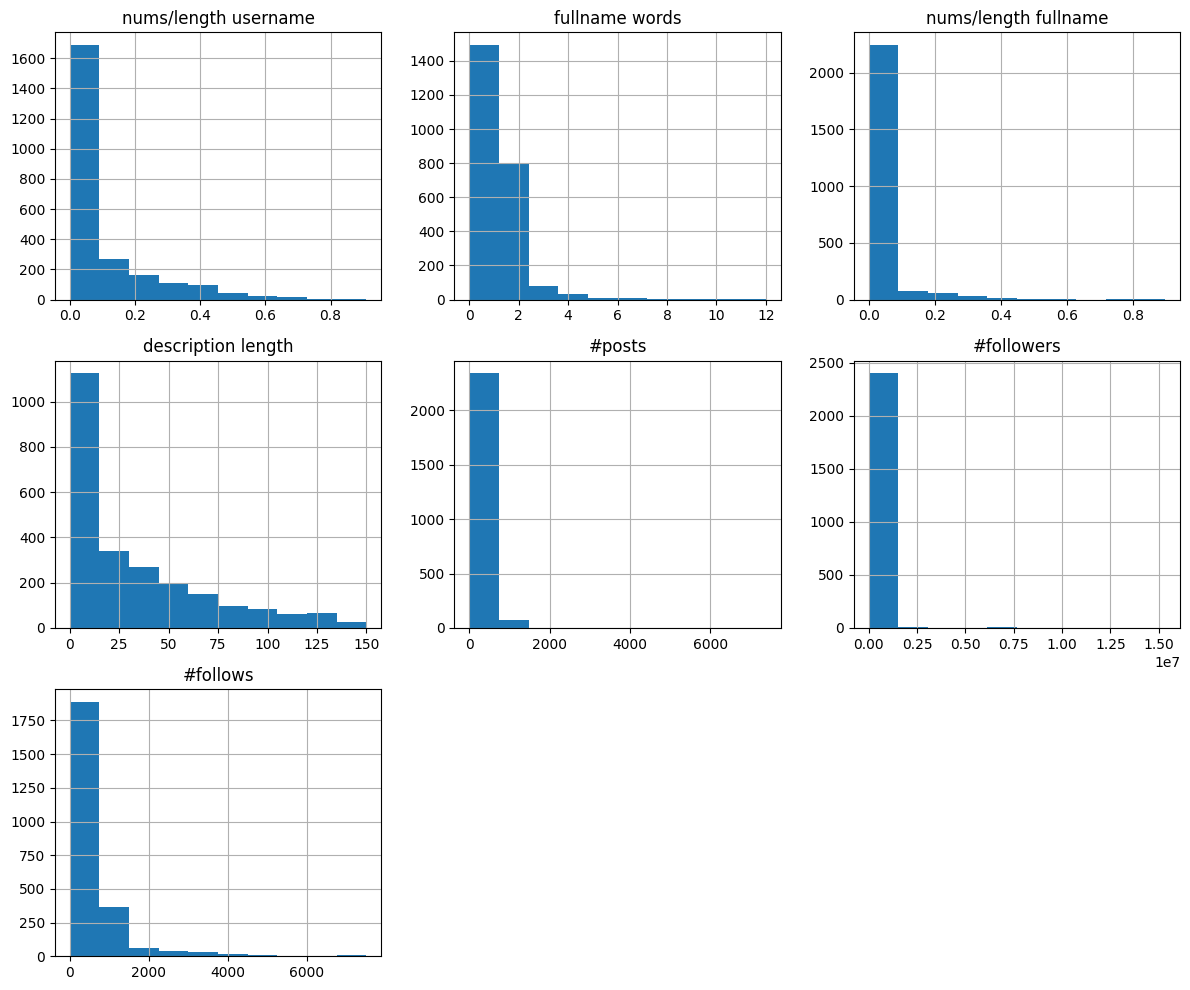

In [106]:
train[numeric_columns].hist(figsize=(12, 10))
plt.tight_layout()
plt.show()

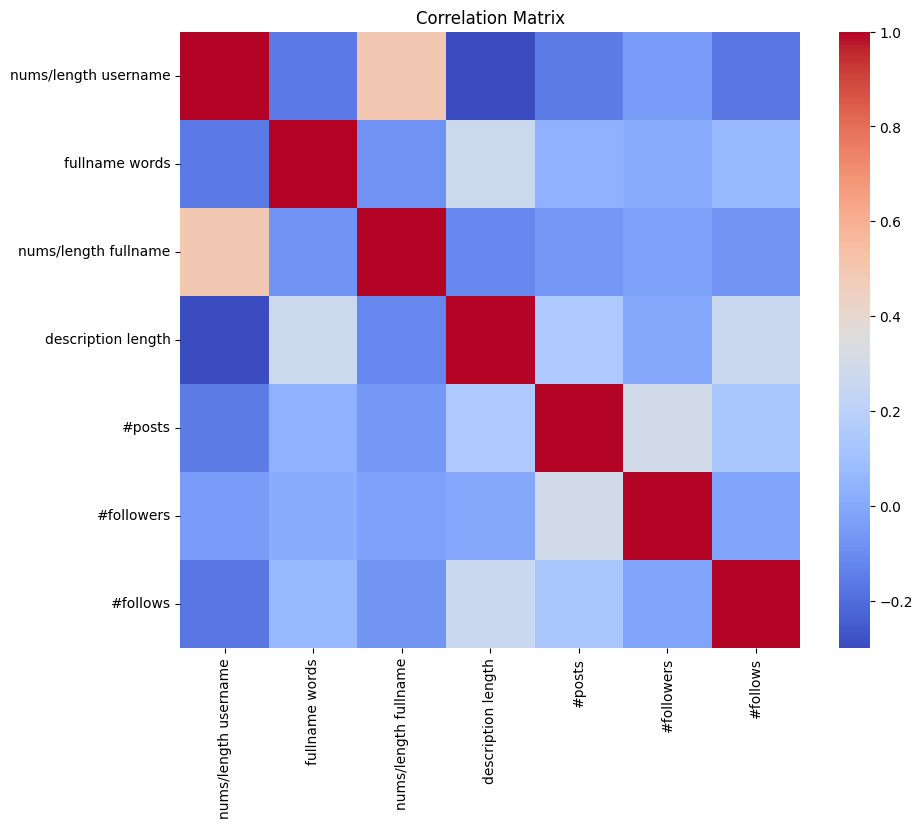

In [115]:
plt.figure(figsize=(10, 8))
sns.heatmap(train[numeric_columns].corr(), annot=False, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

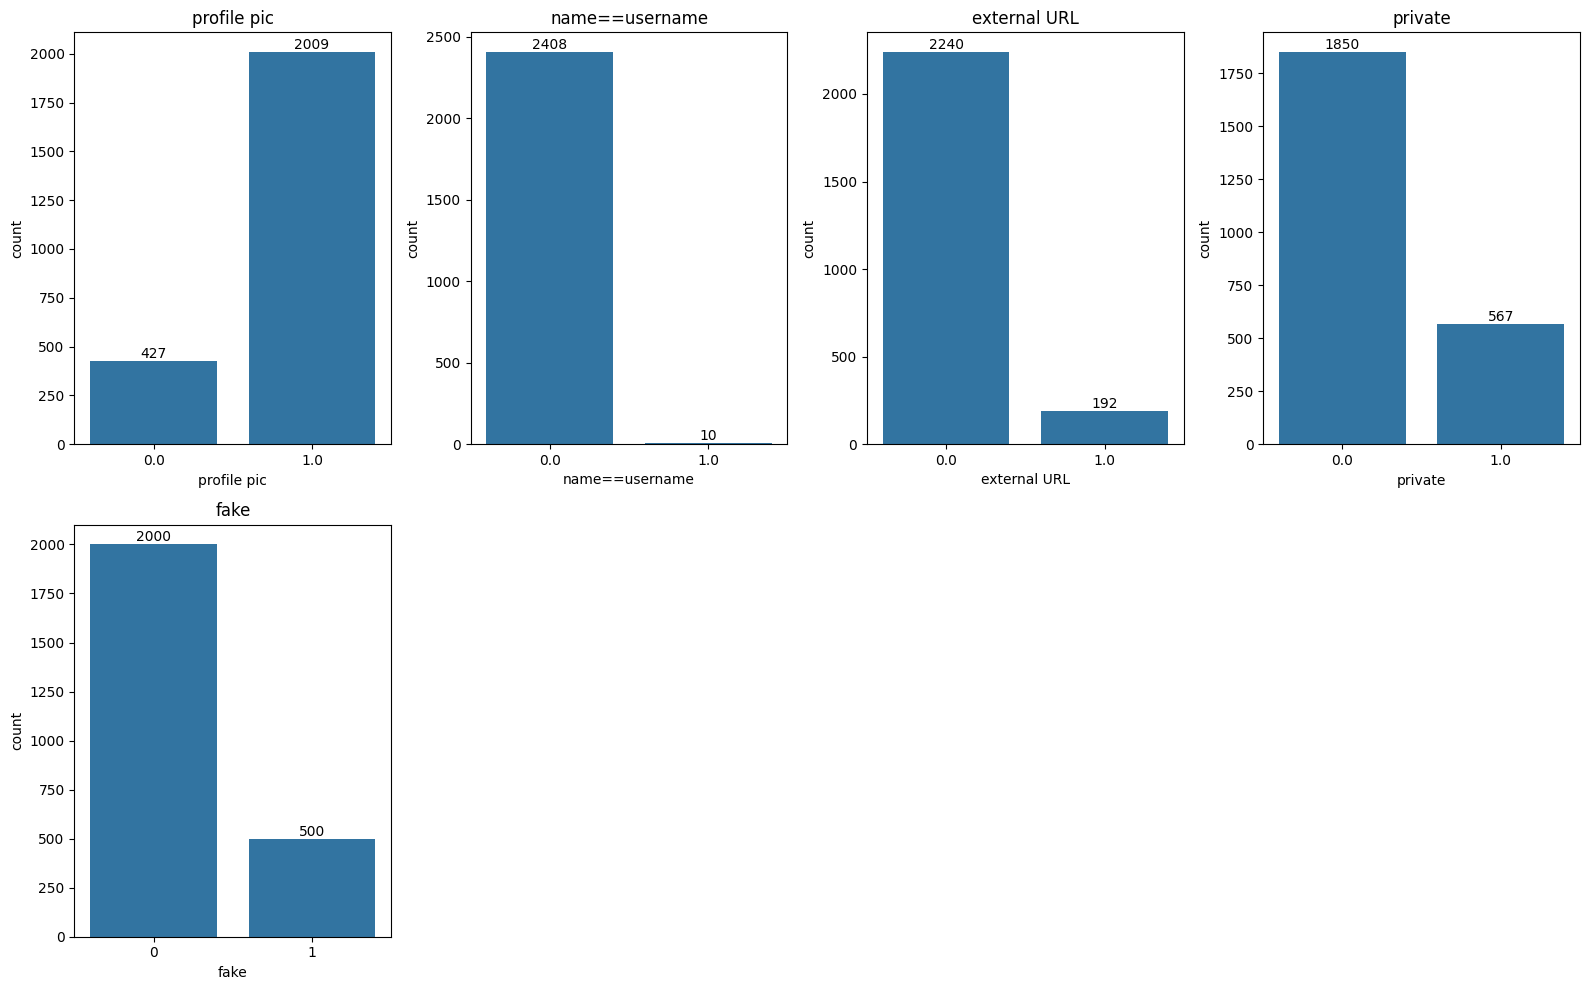

In [113]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

n = len(categorical_cols)
rows = math.ceil(n / 4)
fig, axes = plt.subplots(rows, 4, figsize=(4 * 4, rows * 5))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    ax = axes[i]
    
    sns.countplot(x=train[col], ax=ax)
    ax.set_title(col)
    ax.set_xticks([0, 1])

    for p in ax.patches:
        ax.annotate(
            f"{int(p.get_height())}",
            (p.get_x() + p.get_width() / 2, p.get_height()),
            ha="center",
            va="bottom"
        )

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Analyses that raise issues:

train null values:



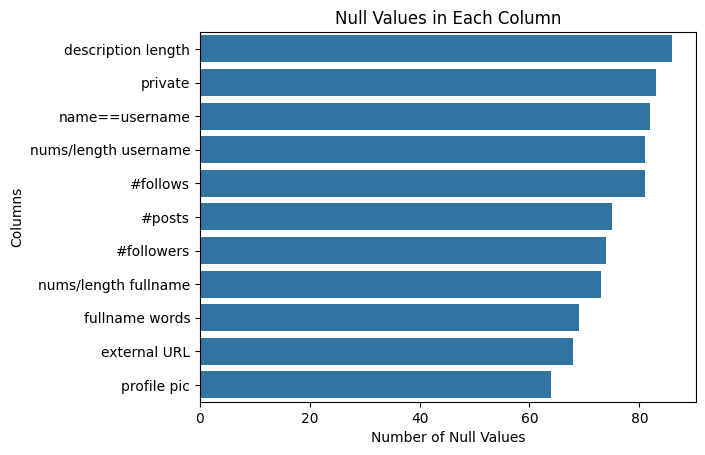

In [109]:
print("train null values:\n")
nulls=train.isnull().sum()
nulls=nulls[nulls>0]
nulls.sort_values(inplace=True, ascending=False)
plt.figure()
sns.barplot(y=nulls.index, x=nulls.values)
plt.title("Null Values in Each Column")
plt.ylabel("Columns")
plt.xlabel("Number of Null Values")
plt.show()


fake
0    2000
1     500
Name: count, dtype: int64


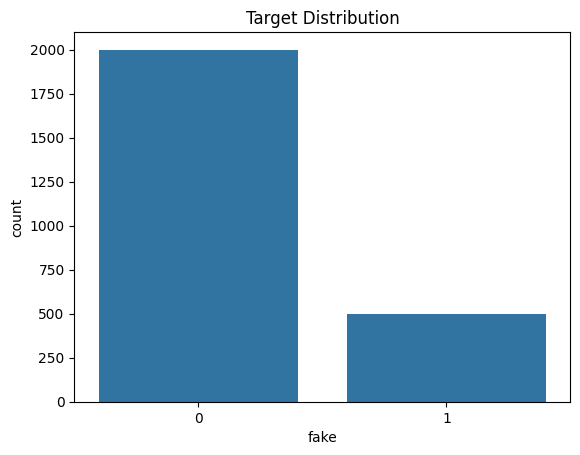

In [110]:
print(train["fake"].value_counts())

plt.figure()
sns.countplot(x=train["fake"])
plt.title("Target Distribution")
plt.show()